In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import os
import seaborn as sns
import sys
sys.path.append("/extdata4/baeklab/Hyeonseo/m6A/modformer")
from utils.utils import printmessage
import glob
import tqdm


In [14]:
path_mrna = "/extdata4/baeklab/Hyeonseo/m6A/inference/inference/AIRNA-DW-v2-20240827-175235-22-373000-token_normalise_dwell_all_npz-ON0090_allmotif_pileup/pileup.pkl"
df_mrna = pd.read_pickle(path_mrna)
df_mrna = df_mrna[df_mrna["count_pm6a"]>=20]
print(df_mrna)

                label_id      pm6a  count_pm6a       dom  count_dom  mean_pred
0         NM_000016:1000  0.000661       257.0  0.000000        258   0.001252
1         NM_000016:1008  0.000804       253.0  0.000000        255   0.001761
2         NM_000016:1009  0.002531       257.0  0.000000        258   0.002951
3         NM_000016:1010  0.003011       253.0  0.011628        258   0.013154
4         NM_000016:1014  0.003508       247.0  0.003968        252   0.008094
...                  ...       ...         ...       ...        ...        ...
30866282    NR_184306:85  0.011885        45.0  0.000000         45   0.011624
30866285    NR_184306:87  0.016118        38.0  0.065217         46   0.084331
30866288    NR_184306:88  0.014161        43.0  0.000000         45   0.020202
30866300    NR_184306:93  0.989961        34.0  0.674419         43   0.665863
30866311    NR_184306:98  0.026973        31.0  0.052632         38   0.076848

[15105481 rows x 6 columns]


In [16]:
print(df_mrna[(df_mrna["pm6a"]>=0.75) & (df_mrna["dom"]>=0.75)])

                label_id      pm6a  count_pm6a       dom  count_dom  mean_pred
2187      NM_000021:1584  0.999212       134.0  0.992908        141   0.986580
2234      NM_000021:1730  0.997136       122.0  0.922535        142   0.903682
2242      NM_000021:1778  0.996782       118.0  0.978571        140   0.963609
2259      NM_000021:1833  0.994888       121.0  0.870504        139   0.861053
2317      NM_000021:2018  0.996063       129.0  0.769784        139   0.759350
...                  ...       ...         ...       ...        ...        ...
30848394   NR_183625:562  0.996863        24.0  0.851852         27   0.820915
30850495  NR_183758:2065  0.997504        20.0  0.840000         25   0.835778
30851337  NR_183824:1111  0.998460        57.0  0.939394         66   0.927656
30851352  NR_183824:1212  0.998128        53.0  0.877193         57   0.876989
30851523  NR_183824:2156  0.998919        59.0  0.983871         62   0.977640

[29079 rows x 6 columns]


In [11]:
path_ivt = "/extdata4/baeklab/Hyeonseo/m6A/inference/inference/AIRNA-DW-v2-20240827-175235-22-373000-token_normalise_all_context_dwell-IVT_ON0105_allmotif_pileup/pileup.pkl"
df_ivt = pd.read_pickle(path_ivt)
df_ivt = df_ivt[df_ivt["count_pm6a"]>=20]
print(df_ivt)

                label_id      pm6a  count_pm6a       dom  count_dom  mean_pred
0         NM_000016:1000  0.002688        63.0  0.000000         68   0.013365
1         NM_000016:1008  0.002567        62.0  0.015625         64   0.016574
2         NM_000016:1009  0.003085        60.0  0.000000         63   0.008780
3         NM_000016:1010  0.005679        63.0  0.028986         69   0.037653
4         NM_000016:1014  0.003921        60.0  0.015385         65   0.026991
...                  ...       ...         ...       ...        ...        ...
11056331    NR_184306:51  0.005826        22.0  0.000000         24   0.016427
11056332    NR_184306:55  0.008886        22.0  0.000000         23   0.013370
11056333    NR_184306:57  0.007244        21.0  0.000000         22   0.011325
11056334    NR_184306:58  0.008669        23.0  0.000000         23   0.008415
11056377    NR_184306:87  0.010210        20.0  0.000000         23   0.027729

[3228977 rows x 6 columns]


In [13]:
print(df_ivt[(df_ivt["pm6a"]>=0.75) & (df_ivt["dom"]>=0.75)])

                   label_id      pm6a  count_pm6a       dom  count_dom  \
509677       NM_001033:2743  0.995936        47.0  0.972973         74   
621531    NM_001042724:2592  0.959341        37.0  0.834711        121   
633575       NM_001064:1085  0.846250        58.0  0.801262        317   
746249     NM_001097615:438  0.976077        33.0  0.818182         88   
1017035   NM_001134335:2140  0.993175        30.0  1.000000         53   
...                     ...       ...         ...       ...        ...   
10334266     NR_033399:3617  0.912483        20.0  0.789474         76   
10386590     NR_036564:1067  0.881488        23.0  0.765957         94   
10415478      NR_037688:465  0.959904       307.0  0.833091       1378   
10428461     NR_037926:3083  0.975667       222.0  0.816832        606   
11029266      NR_173351:438  0.934684        21.0  0.777778         63   

          mean_pred  
509677     0.938532  
621531     0.763296  
633575     0.685465  
746249     0.749146  
1

In [24]:

def process_dorado_inferece(data_path):
    
    if os.path.exists(data_path.replace(".bed", ".pkl")):
        data_df = pd.read_pickle(data_path.replace(".bed", ".pkl"))
        return data_df
    else:
        data_df = pd.read_csv(data_path, quoting = 3, sep = "\t", header = None, dtype=str)
        ## Keep column 0, 1, 4, 9
        data_df = data_df[[0, 1, 4, 9]]
        data_df.columns = ["nmid", "pos", "depth", "pred_dorado"]
        data_df["depth"] = data_df["depth"].astype(int)
        data_df["pred_dorado"] = data_df["pred_dorado"].str.split(" ").str[1].astype(float) / 100
        data_df["label_id"] = data_df["nmid"].str.split(".").str[0] + ":" + data_df["pos"]
        data_df = data_df[["label_id", "pred_dorado","depth"]].copy()
        data_df.rename(columns = {"depth": "dorado_count"}, inplace = True)
        data_df.to_pickle(data_path.replace(".bed", ".pkl"))
    
        return data_df

In [21]:
dorado_ivt = process_dorado_inferece("/extdata4/baeklab/Hyeonseo/m6A/runs/exp_MRNA/ON0105/ON0105/result/intermediates/old/dorado_output.modkit.bed")
print(dorado_ivt)

                label_id  pred_dorado  dorado_count
0          NM_000015:688          0.0             1
1          NM_000015:690          0.0             1
2          NM_000015:692          0.0             1
3          NM_000015:698          0.0             1
4          NM_000015:700          0.0             1
...                  ...          ...           ...
43489423  NR_184563:6132          0.0             1
43489424  NR_184563:6137          0.0             1
43489425  NR_184563:6139          0.0             1
43489426  NR_184563:6140          0.0             1
43489427  NR_184563:6142          0.0             1

[43489428 rows x 3 columns]


In [22]:
dorado_ivt = dorado_ivt[dorado_ivt["dorado_count"]>=20]
print(dorado_ivt)
print(dorado_ivt[(dorado_ivt["pred_dorado"]>=0.5)])
print(dorado_ivt[(dorado_ivt["pred_dorado"]>=0.75)])

               label_id  pred_dorado  dorado_count
193         NM_000016:0       0.2083            24
194         NM_000016:2       0.0000            35
195         NM_000016:5       0.0250            40
199        NM_000016:21       0.0351            57
201        NM_000016:24       0.0980            51
...                 ...          ...           ...
43487047  NR_184306:322       0.0909            22
43487048  NR_184306:326       0.1500            20
43487049  NR_184306:330       0.0000            24
43487050  NR_184306:331       0.0000            24
43487051  NR_184306:333       0.0000            27

[3579752 rows x 3 columns]
                label_id  pred_dorado  dorado_count
519        NM_000016:537       0.7500            48
2019      NM_000018:1076       0.5946            74
2179      NM_000018:1373       0.5000            62
2403      NM_000018:1778       0.6837            98
2625        NM_000019:79       0.6941            85
...                  ...          ...           

In [26]:
dorado_mrna = process_dorado_inferece("/extdata4/baeklab/Hyeonseo/m6A/runs/exp_MRNA/ON0090/ON0090/result/dorado-070-aligned/intermediates/dorado_output.bed")
print(dorado_mrna)
dorado_mrna = dorado_mrna[dorado_mrna["dorado_count"] >= 20]
print(dorado_mrna)
print(dorado_mrna[(dorado_mrna["pred_dorado"] >= 0.5)])
print(dorado_mrna[(dorado_mrna["pred_dorado"] >= 0.75)])

               label_id  pred_dorado  dorado_count
413         NM_000016:0       0.5250            40
414         NM_000016:2       0.0164            61
415         NM_000016:5       0.0822            73
417        NM_000016:21       0.0250           160
418        NM_000016:24       0.0710           155
...                 ...          ...           ...
59475965  NR_184306:326       0.1795            39
59475966  NR_184306:330       0.0488            41
59475967  NR_184306:331       0.0000            40
59475968  NR_184306:333       0.0000            41
59475969  NR_184306:334       0.0000            24

[15457254 rows x 3 columns]
               label_id  pred_dorado  dorado_count
413         NM_000016:0       0.5250            40
414         NM_000016:2       0.0164            61
415         NM_000016:5       0.0822            73
417        NM_000016:21       0.0250           160
418        NM_000016:24       0.0710           155
...                 ...          ...           ...
59

In [36]:
def estimate_fdr_fpr(dorado_mrna, dorado_ivt, airna_mrna, airna_ivt):
    threshold = np.arange(0.0, 1.0, 0.01)
    dorado_fdr_list = []
    airna_fdr_list = []
    dorado_fpr_list = []
    airna_fpr_list = []
    dorado_mrna = np.sort(dorado_mrna["pred_dorado"].values)
    dorado_ivt = np.sort(dorado_ivt["pred_dorado"].values)
    airna_mrna = np.sort(airna_mrna["pm6a"].values)
    airna_ivt = np.sort(airna_ivt["pm6a"].values)
    
    for t in threshold:
        dorado_ivt_positive_frac = np.sum(dorado_ivt >= t) / len(dorado_ivt)
        dorado_mrna_positive_frac = np.sum(dorado_mrna >= t) / len(dorado_mrna)
        airna_ivt_positive_frac = np.sum(airna_ivt >= t) / len(airna_ivt)
        airna_mrna_positive_frac = np.sum(airna_mrna >= t) / len(airna_mrna)
        dorado_fdr_list.append(dorado_ivt_positive_frac / dorado_mrna_positive_frac)
        airna_fdr_list.append(airna_ivt_positive_frac / airna_mrna_positive_frac)
        dorado_fpr_list.append(dorado_ivt_positive_frac)
        airna_fpr_list.append(airna_ivt_positive_frac)
    
    df = pd.DataFrame({"dorado_fdr": dorado_fdr_list, "airna_fdr": airna_fdr_list, "dorado_fpr": dorado_fpr_list, "airna_fpr": airna_fpr_list, "threshold": threshold})
    
    return df



    
    

In [39]:
print(dorado_mrna)
print(dorado_ivt)
print(df_mrna)
print(df_ivt)


df = estimate_fdr_fpr(dorado_mrna, dorado_ivt, df_mrna, df_ivt)
df[['dorado_fdr', 'airna_fdr', 'dorado_fpr', 'airna_fpr']] = np.clip(df[['dorado_fdr', 'airna_fdr', 'dorado_fpr', 'airna_fpr']], 0, 1)
print(df)

               label_id  pred_dorado  dorado_count
413         NM_000016:0       0.5250            40
414         NM_000016:2       0.0164            61
415         NM_000016:5       0.0822            73
417        NM_000016:21       0.0250           160
418        NM_000016:24       0.0710           155
...                 ...          ...           ...
59475965  NR_184306:326       0.1795            39
59475966  NR_184306:330       0.0488            41
59475967  NR_184306:331       0.0000            40
59475968  NR_184306:333       0.0000            41
59475969  NR_184306:334       0.0000            24

[15457254 rows x 3 columns]
               label_id  pred_dorado  dorado_count
193         NM_000016:0       0.2083            24
194         NM_000016:2       0.0000            35
195         NM_000016:5       0.0250            40
199        NM_000016:21       0.0351            57
201        NM_000016:24       0.0980            51
...                 ...          ...           ...
43

Text(0.5, 1.0, 'FDR vs. Threshold')

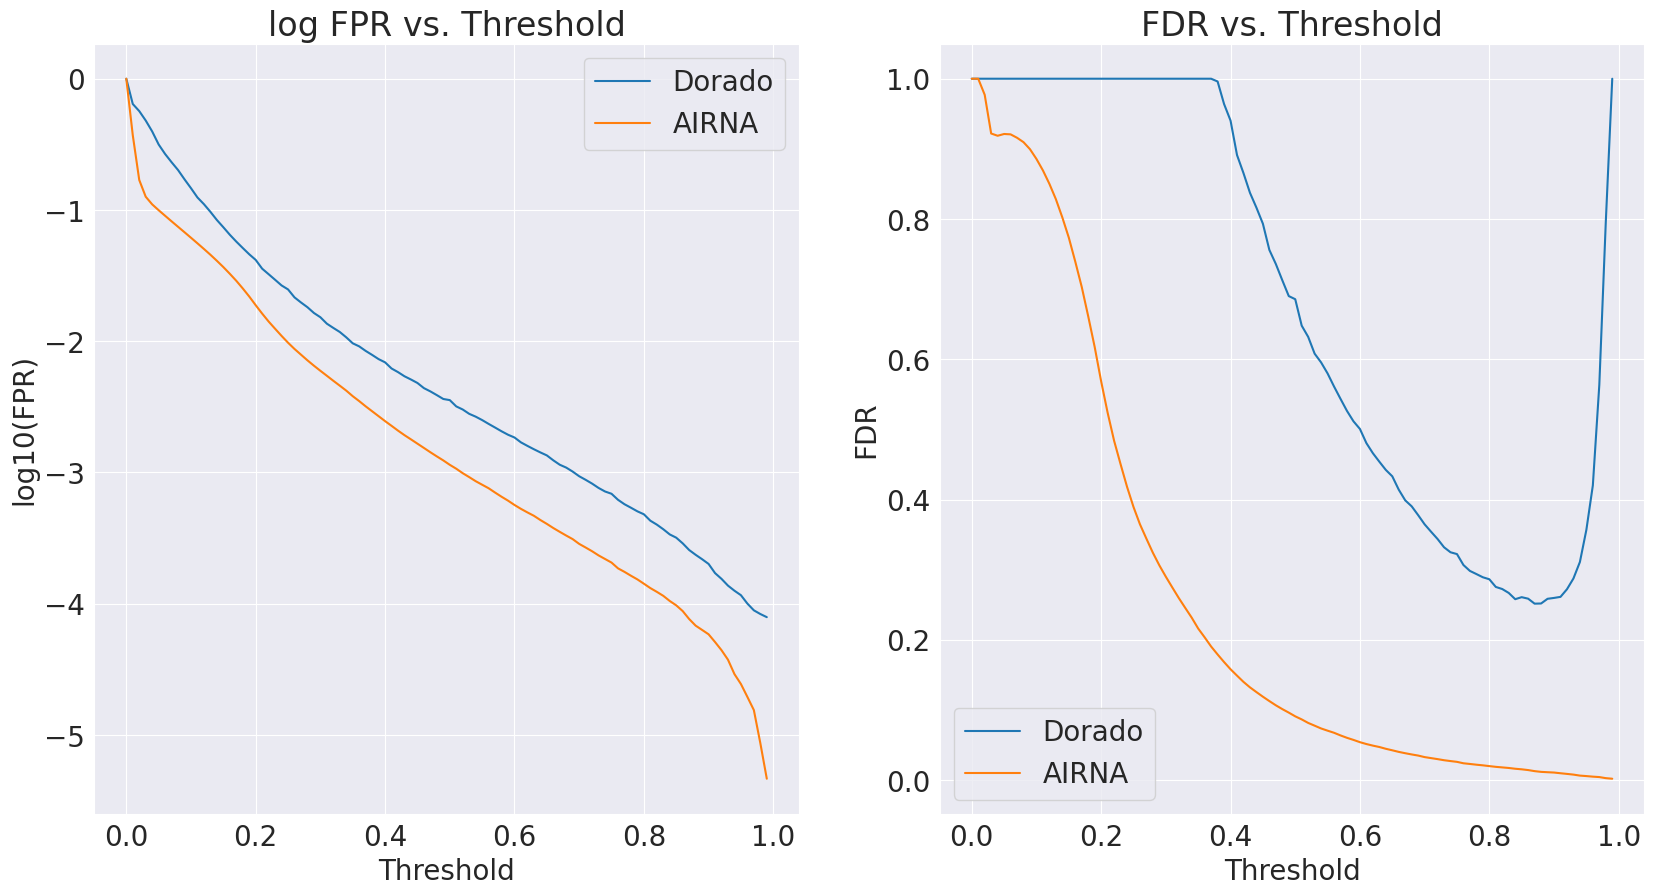

In [48]:

plt.rcParams.update({'font.size': 20})
fig, axes = plt.subplots(1, 2, figsize=(20, 10))

## plot 1. log10(FPR)
axes[0].plot(df["threshold"], np.log10(df["dorado_fpr"]), label = "Dorado")
axes[0].plot(df["threshold"], np.log10(df["airna_fpr"]), label = "AIRNA")
axes[0].set_xlabel("Threshold")
axes[0].set_ylabel("log10(FPR)")
axes[0].legend()
axes[0].set_title("log FPR vs. Threshold")

## plot 2. FDR
axes[1].plot(df["threshold"], df["dorado_fdr"], label = "Dorado")
axes[1].plot(df["threshold"], df["airna_fdr"], label = "AIRNA")
axes[1].set_xlabel("Threshold")
axes[1].set_ylabel("FDR")
axes[1].legend()
axes[1].set_title("FDR vs. Threshold")


